In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
from torch.nn import LayerNorm

In [2]:
!pip install thop
!pip install tdqm

# Part 1: Attention and Encoder-Decoder Models

In this section, you'll implement two forms of attention and use them in an encoder-decoder style transformer. You'll then compare performance based on changing dataset size and hidden dimension.

## Step 1: Scaled Dot Product Attention
Implement both the base `scaled_dot_attention` method as well as the `forward` method for the `Attention` module.

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:


def scaled_dot_attention(q, k, v, mask=0):
  """Computes scaled dot product attention with an optional mask.
    q : shape ( batch, k, hidden_size)
    k : shape ( batch, seq_len, hidden_size)
    v : shape ( batch, seq_len, hidden_size)
    mask: optional. shape (k, seq_len)

  returns:
      context   : shape (batch, k, hidden_size)
      attention : shape (batch, k, seq_len)
  """

  # ------------
  # FILL THIS IN
  # ------------
  _, _, hidden_size = q.shape
  k_t = k.transpose(1, 2)
  unnorm_attn = torch.bmm(q, k_t)
  masked_unnorm_attn = unnorm_attn + mask
  attention = nn.Softmax(dim=2)(masked_unnorm_attn / hidden_size**0.5)
  context = torch.bmm(attention, v)
  return context, attention

In [5]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.hidden_size = hidden_size

    def forward(self, x, annots):
        #   x         : shape ( batch, k, hidden_size)
        #   annots    : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # Pay attention to which inputs you use for the queries, keys, and values.
        # ------------
        q = self.Q(x)
        k = self.K(annots)
        v = self.V(annots)
        return scaled_dot_attention(q, k, v)

## Step 2: Causal Scaled Dot Product Attention
Using your `scaled_dot_attention` method, implement the `forward` method for the `CausalAttention` module.


In [6]:
class CausalAttention(Attention):
    def __init__(self, hidden_size):
        super().__init__(hidden_size)

    def forward(self, x):
        #   x : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # This should be very similar to your other attention implementation,
        # with the exception that you only have one set of outputs and you
        # must construct a causal attention mask.
        # ------------
        _, seq_len, _ = x.shape
        q = self.Q(x)
        k = self.K(x)
        v = self.V(x)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf')).masked_fill(mask == 0, 0.0).to(device)
        return scaled_dot_attention(q, k, v, mask)

#### Simple test cases
##### Passing this DOES NOT mean your implementation is correct. But, if this fails, then you definitely did something wrong

In [7]:
cros_attn = Attention(32).to(device)
caus_attn = CausalAttention(32).to(device)
caus_attn.Q = cros_attn.Q
caus_attn.K = cros_attn.K
caus_attn.V = cros_attn.V

inp = torch.randn(4, 8, 32).to(device)
inp2 = torch.randn(4, 16, 32).to(device)

print("Checking consistent shape")
assert cros_attn(inp, inp2)[0].shape == inp.shape
assert caus_attn(inp)[0].shape == inp.shape
assert cros_attn(inp, inp2)[1].shape == (4, 8, 16)
assert caus_attn(inp)[1].shape == (4, 8, 8)

print("Checking attention mask")
assert torch.all(caus_attn(inp)[0][:, -1] == cros_attn(inp, inp)[0][:, -1])

print("Passed")

Checking consistent shape
Checking attention mask
Passed


#### Read through the following code. Make sure you understand what is going on.
This code sets up the encoder-decoder architecture. It requires no additional code.

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, hidden_size, max_len = 1000):
        super().__init__()

        pos = torch.arange(max_len).float().unsqueeze(1)   # [max_len, 1]
        dim = torch.arange(hidden_size // 2).float().unsqueeze(0) # [1, hidden_size // 2]

        div_term = torch.exp(-math.log(10000.0) * (2 * dim) / hidden_size)
        angle = pos * div_term

        pe = torch.zeros(max_len, hidden_size)
        pe[:, 0::2] = torch.sin(angle)
        pe[:, 1::2] = torch.cos(angle)

        self.register_buffer("pe", pe)

    def forward(self, idx):
        return self.pe[idx]

In [9]:
class MLP(nn.Module):

    def __init__(self, hidden_size):
        super().__init__()
        self.layer1  = nn.Linear(hidden_size, hidden_size, bias=False)
        self.layer2  = nn.Linear(hidden_size, hidden_size, bias=False)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

class EncoderBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = Attention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x):
        context, attention = self.attn(self.norm1(x), self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention

class DecoderBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.cros_attn = Attention(hidden_size)
        self.self_attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x, annotation):
        context, self_attn = self.self_attn(self.norm1(x))
        x = x + context
        context, cros_attn = self.cros_attn(self.norm2(x), annotation)
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, self_attn, cros_attn

In [10]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.encoder_blocks = nn.ModuleList(
            [EncoderBlock(hidden_size) for i in range(num_layers)]
        )
        self.decoder_blocks = nn.ModuleList(
            [DecoderBlock(hidden_size) for i in range(num_layers)]
        )

        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

        self.apply(self._init_weights) # initialize the weights to a small number

    def forward(self, inputs, annots):

        pos_x = torch.arange(0, inputs.shape[-1], device=inputs.device).long() # creates tensor([0, 1, 2, 3, ...])
        pos_y = torch.arange(0, annots.shape[-1], device=inputs.device).long() # creates tensor([0, 1, 2, 3, ...])

        x = self.tok_emb(inputs) + self.pos_emb(pos_x)
        y = self.tok_emb(annots) + self.pos_emb(pos_y)

        self_attn = []
        cros_attn = []

        for encode in self.encoder_blocks:
            y, _ = encode(y)

        for decode in self.decoder_blocks:
            x, s, c = decode(x, y)
            cros_attn.append(c)
            self_attn.append(s)

        return self.head(x), {'self_attn': self_attn, 'cros_attn': cros_attn}

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

## Step 3: Training the model

You'll now train a set of example models. This section requires no additional code from you, with the exception of setting the datapath. However, **you are required to analyze and include some of its output**.

In [11]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.insert(0, '/content/drive/MyDrive/NNDL_hw2/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [12]:
import os
os.listdir('/content/drive/MyDrive/NNDL_hw2/')

['pig_latin_small.txt',
 'pig_latin_large.txt',
 '__pycache__',
 'hw_trainer.py',
 'hw_utils.py',
 'hw_dataset.py']

In [13]:
script_path = '/content/drive/MyDrive/NNDL_hw2/pig_latin_small.txt'
if os.path.exists(script_path):
    print(f"File found at {script_path}")
else:
    print(f"File not found at {script_path}")

File found at /content/drive/MyDrive/NNDL_hw2/pig_latin_small.txt


In [14]:
from hw_dataset import EncoderDecoderDataset, DecoderDataset
from hw_utils import save_loss_comparison_by_dataset, save_loss_comparison_by_hidden
from torch.utils.data import DataLoader
from hw_trainer import train
import torch.optim as optim

data_path = '/content/drive/MyDrive/NNDL_hw2/' # Change data_path to where the data is stored

encdec_ds_small = EncoderDecoderDataset(data_path, 'pig_latin_small')
encdec_ds_large = EncoderDecoderDataset(data_path, 'pig_latin_large')


In [15]:
print("device: ", device)
print("Dataset sample:")
print("Input:", encdec_ds_small.to_token(encdec_ds_small[0][0].tolist()))
print("Annotation:", encdec_ds_small.to_token(encdec_ds_small[0][1].tolist()))
print("Target:", encdec_ds_small.to_token(encdec_ds_small[0][2].tolist()))

device:  cuda
Dataset sample:
Input: <SOS>appetiteway
Annotation: appetite
Target: appetiteway<EOS>


In [16]:
model = TransformerEncoderDecoder(
    vocab_size = len(encdec_ds_small.idx_to_token),
    hidden_size = 16,
    num_layers = 4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=encdec_ds_small,
    num_epochs=25,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size = 32
)

Epoch 1 | Train loss: 2.597894 | Val loss 2.331676
Epoch 2 | Train loss: 2.144210 | Val loss 2.008029
Epoch 3 | Train loss: 1.871214 | Val loss 1.714172
Epoch 4 | Train loss: 1.578720 | Val loss 1.311347
Epoch 5 | Train loss: 1.156776 | Val loss 1.020665
Epoch 6 | Train loss: 0.841635 | Val loss 0.729248
Epoch 7 | Train loss: 0.596280 | Val loss 0.502279
Epoch 8 | Train loss: 0.428334 | Val loss 0.382569
Epoch 9 | Train loss: 0.302875 | Val loss 0.377396
Epoch 10 | Train loss: 0.256246 | Val loss 0.225700
Epoch 11 | Train loss: 0.211373 | Val loss 0.213004
Epoch 12 | Train loss: 0.185748 | Val loss 0.183159
Epoch 13 | Train loss: 0.153735 | Val loss 0.244506
Epoch 14 | Train loss: 0.137479 | Val loss 0.140772
Epoch 15 | Train loss: 0.129889 | Val loss 0.142118
Epoch 16 | Train loss: 0.101851 | Val loss 0.142718
Epoch 17 | Train loss: 0.103458 | Val loss 0.130507
Epoch 18 | Train loss: 0.089397 | Val loss 0.169710
Epoch 19 | Train loss: 0.087456 | Val loss 0.172380
Epoch 20 | Train loss

In [17]:
def encdec_generate(input, model, dataset, max_len=20):
    gen_string = ""
    idx = torch.tensor([[dataset.start_idx]]).to(device)
    annots = torch.tensor([dataset.to_idx(input) + [dataset.end_idx]*(max(0, 12-len(input)))]).to(device)
    #pad the input string with <EOS> since the collate_fn had to pad the stirngs

    for i in range(max_len):
        logits = model(idx, annots)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string

def encdec_translate(sentence, model, dataset):
    words = sentence.split()
    return " ".join([encdec_generate(w, model, dataset) for w in words])

In [18]:
encdec_translate('the', model, encdec_ds_small)

'ethay'

In [19]:
encdec_translate("the air conditioning is working", model, encdec_ds_small)

'ethay airway onditioninggay isiay orkingway'

In [20]:
encdec_translate("testing some random words", model, encdec_ds_small)

'estingtay omesay andomray ordsway'


Training model: hidden_size=16, dataset=small
Epoch 1 | Train loss: 2.647814 | Val loss 2.274021
Epoch 2 | Train loss: 2.148379 | Val loss 1.985065
Epoch 3 | Train loss: 1.914154 | Val loss 1.804677
Epoch 4 | Train loss: 1.632637 | Val loss 1.376427
Epoch 5 | Train loss: 1.172449 | Val loss 0.912591
Epoch 6 | Train loss: 0.777401 | Val loss 0.612694
Epoch 7 | Train loss: 0.570023 | Val loss 0.452083
Epoch 8 | Train loss: 0.444350 | Val loss 0.424059
Epoch 9 | Train loss: 0.324624 | Val loss 0.322274
Epoch 10 | Train loss: 0.258161 | Val loss 0.217494
Epoch 11 | Train loss: 0.202434 | Val loss 0.303236
Epoch 12 | Train loss: 0.166889 | Val loss 0.188001
Epoch 13 | Train loss: 0.149824 | Val loss 0.189959
Epoch 14 | Train loss: 0.114383 | Val loss 0.131827
Epoch 15 | Train loss: 0.114256 | Val loss 0.129113
Epoch 16 | Train loss: 0.100125 | Val loss 0.152866
Epoch 17 | Train loss: 0.087166 | Val loss 0.110779
Epoch 18 | Train loss: 0.073392 | Val loss 0.121935
Epoch 19 | Train loss: 0.0

<Figure size 640x480 with 0 Axes>

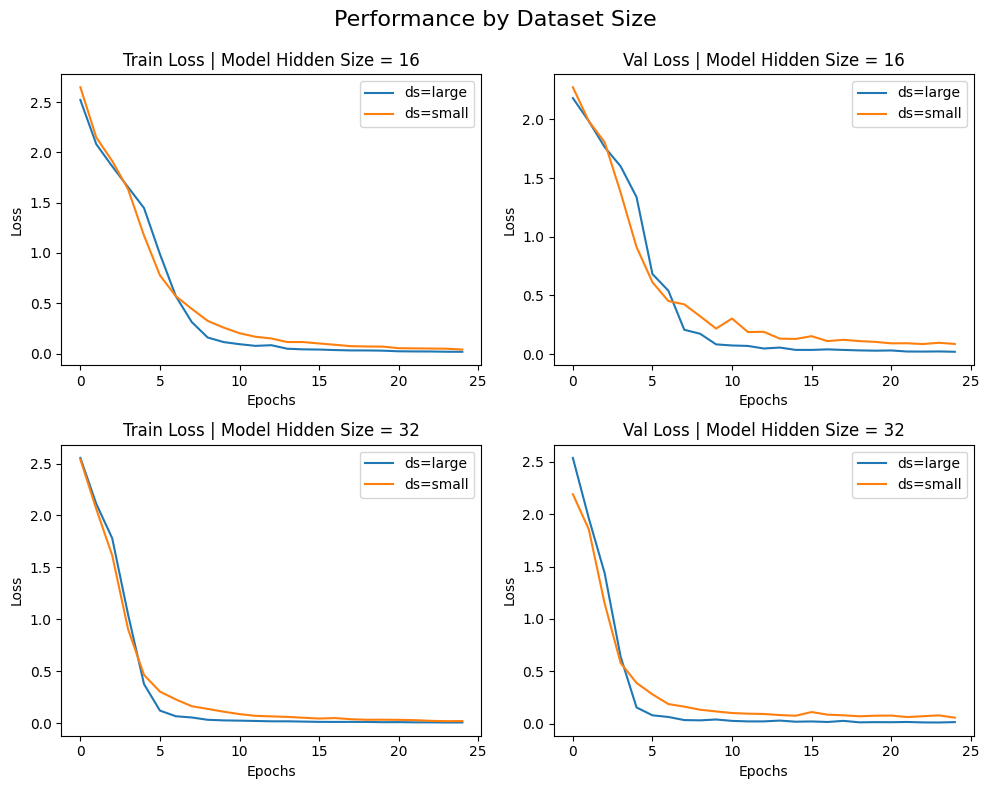

<Figure size 640x480 with 0 Axes>

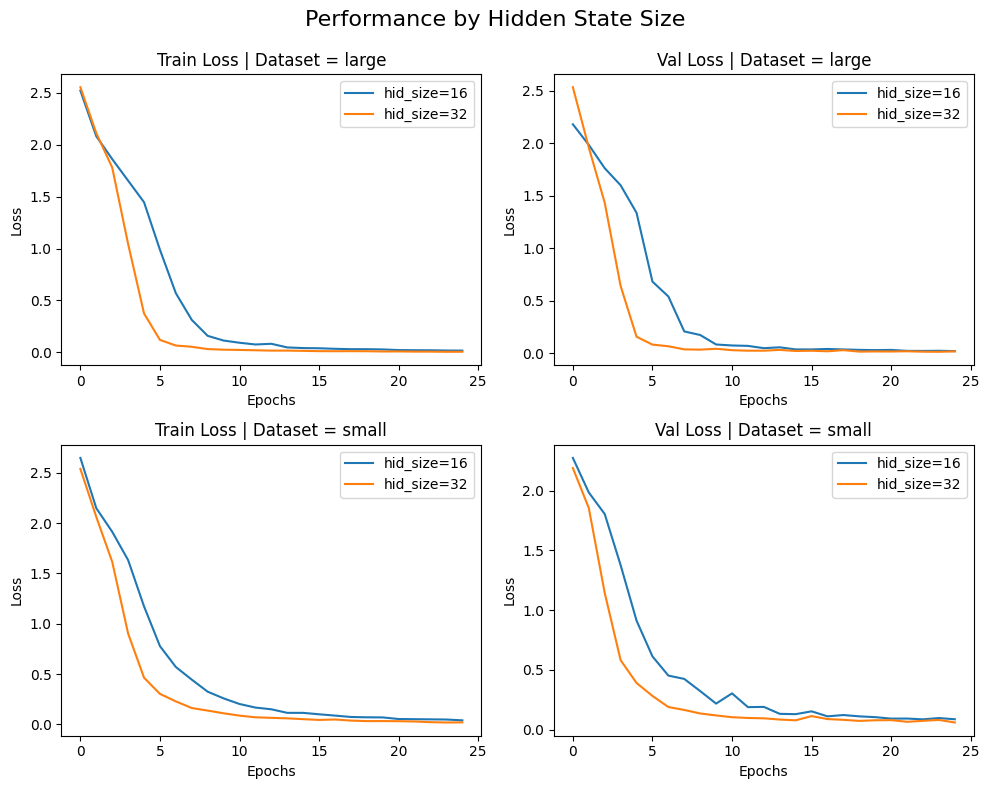

In [21]:
configs = [
    (16, 'small', encdec_ds_small),
    (16, 'large', encdec_ds_large),
    (32, 'small', encdec_ds_small),
    (32, 'large', encdec_ds_large)
]

all_results = {}

for hidden_size, dataset_name, dataset in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, dataset={dataset_name}")

    model = TransformerEncoderDecoder(
        vocab_size=len(dataset.idx_to_token),
        hidden_size=hidden_size,
        num_layers=4
    )
    optimizer = optim.AdamW(model.parameters(), lr=1e-2)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = dataset,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = 32 if dataset_name == "small" else 256
    )
    all_results[(hidden_size, dataset_name)] = results

save_loss_comparison_by_dataset(all_results)
save_loss_comparison_by_hidden(all_results)

# Part 2: Decoder-only Transformers and Multi-Head Attention

In this section, you'll train transformers that only use a decoder instead of a dual encoder-decoder architecture. You'll also implement and experiment with multi-head attention. Finally, you'll compare increasing parameter count with multi-head attention vs. increasing the parameter count with a larger hidden dimensionality.

## Step 1: Implement the Decoder-Only Forward Method

In [22]:
class DecoderOnlyBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x):
        context, attention = self.attn(self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention

class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.blocks = nn.ModuleList(
            [DecoderOnlyBlock(hidden_size) for i in range(num_layers)]
        )
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

    def forward(self, inputs):
        """Forward pass of the Transformer decoder.

        Arguments:
            inputs: Input token indexes across a batch for all the time step. (batch_size x decoder_seq_len)
        Returns:
            output: Un-normalized scores for each token in the vocabulary, across a batch for all the decoding time steps. (batch_size x decoder_seq_len x vocab_size)
            attentions: The stacked attention weights applied to the encoder annotations (batch_size x encoder_seq_len x decoder_seq_len) ? (batch_size x decoder_seq_len x num_layers)
        """
        # ------------
        # FILL THIS IN
        # ------------
        pos = torch.arange(0, inputs.shape[-1], device=inputs.device).long()
        x = self.tok_emb(inputs) + self.pos_emb(pos)
        self_attn = []

        for block in self.blocks:
            x, s = block(x)
            self_attn.append(s)

        unormalized_scores = self.head(x)
        # unormalized_scores = nn.Softmax(dim=2)(x)

        return unormalized_scores, {'self_attn': self_attn}

In [23]:
decoder_ds_small = DecoderDataset(data_path, 'pig_latin_small')
decoder_ds_large = DecoderDataset(data_path, 'pig_latin_large')

In [24]:
print("Dataset sample:")
print("Input:", decoder_ds_small.to_token(decoder_ds_small[0][0].tolist()))
print("Target:", decoder_ds_small.to_token(decoder_ds_small[0][1].tolist()))

Dataset sample:
Input: <SOS>appetite<EOP>appetiteway
Target: appetite<EOP>appetiteway<EOS>


## Step 2: Format for decoder-only generation.

Implement the missing line in `decoder_generate` to create an input string that looks like:

```
<SOS> input sequence <EOP>
```
You should use the `dataset.start_idx`, `dataset.eop_idx` attributes and the `dataset.to_idx()` method.

In [25]:
def decoder_generate(input, model, dataset, max_len=20):
    gen_string = ""
    idx = dataset.to_idx(input)
    idx.insert(0, dataset.start_idx)
    idx.append(dataset.eop_idx)
    idx = torch.tensor([idx]).to(device)

    for i in range(max_len):
        logits = model(idx)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string

def decoder_translate(sentence, model, dataset):
    words = sentence.split()
    return " ".join([decoder_generate(w, model, dataset) for w in words])

## Step 3: Train the model

We'll now train a decoder only model and test it out on an example. Use the output of this to guide your answer for question 3.

In [26]:


model = DecoderTransformer(
    vocab_size = len(decoder_ds_small.idx_to_token),
    hidden_size = 16,
    num_layers = 4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model = model,
    dataset = decoder_ds_small,
    num_epochs = 25,
    optimizer = optimizer,
    scheduler = scheduler,
    device = device,
    batch_size = 32
)

Epoch 1 | Train loss: 3.012632 | Val loss 1.800507
Epoch 2 | Train loss: 1.666327 | Val loss 1.484025
Epoch 3 | Train loss: 1.320433 | Val loss 1.172348
Epoch 4 | Train loss: 1.014554 | Val loss 0.845438
Epoch 5 | Train loss: 0.777641 | Val loss 0.703774
Epoch 6 | Train loss: 0.622348 | Val loss 0.574150
Epoch 7 | Train loss: 0.517071 | Val loss 0.497381
Epoch 8 | Train loss: 0.426410 | Val loss 0.414963
Epoch 9 | Train loss: 0.377928 | Val loss 0.387919
Epoch 10 | Train loss: 0.319793 | Val loss 0.281626
Epoch 11 | Train loss: 0.271879 | Val loss 0.374600
Epoch 12 | Train loss: 0.252473 | Val loss 0.242289
Epoch 13 | Train loss: 0.219776 | Val loss 0.283377
Epoch 14 | Train loss: 0.205134 | Val loss 0.216525
Epoch 15 | Train loss: 0.191368 | Val loss 0.210772
Epoch 16 | Train loss: 0.161263 | Val loss 0.171162
Epoch 17 | Train loss: 0.150083 | Val loss 0.148566
Epoch 18 | Train loss: 0.130134 | Val loss 0.165478
Epoch 19 | Train loss: 0.128260 | Val loss 0.233257
Epoch 20 | Train loss

In [27]:
decoder_translate("the air conditioning is working", model, decoder_ds_small)

'ethay airway onditiongcaycay isway orkingway'

## Step 4: Implement Multi-Head Attention

In this next step, you'll implement multi-head attention. In this setting, we'll have the dimensionality for each of the heads be (total hidden dimensionality)/(number of heads). We'll use a projection head to combine the outputs of these different attention heads after concatenating their outputs together (which can also be achieved using tensor reshaping).

In [28]:


# TO DO:

def multihead_scaled_dot_attention(q, k, v, mask=0):
    """ Compute multi-head dot product attention.
      q : shape (batch, num_heads, k, hidden_size)
      k : shape (batch, num_heads, seq_len, hidden_size)
      v : shape (batch, num_heads, seq_len, hidden_size)

    returns:
        context   : shape (batch, num_heads, k, hidden_size)
        attention : shape (batch, num_heads, k, seq_len)
    """
    # Hint: if you implemented scaled_dot_attention well, the code for this should be the exact same.

    # ------------
    # FILL THIS IN
    # ------------
    hidden_size = q.shape[-1]
    unnorm_attn = torch.matmul(q, k.transpose(2, 3))
    # print(f"attn shape {unnorm_attn.shape} mask {mask.shape}")
    masked_unnorm_attn = unnorm_attn + mask
    attention = nn.Softmax(dim=-1)(masked_unnorm_attn / hidden_size ** 0.5)
    context = torch.matmul(attention, v)
    return context, attention

In [29]:
class MultiheadCausalAttention(Attention):
    def __init__(self, hidden_size, num_heads):
        super().__init__(hidden_size)
        # self.Q, self.K, self.V already defined as nn.Linear(hidden_size, hidden_size)
        self.num_heads = num_heads
        # ------------
        # FILL THIS IN
        # ------------
        if self.num_heads > 1:
          self.proj = nn.Linear( hidden_size, hidden_size, bias=False)


    def forward(self, x):

        """ Compute causal multi-head dot product attention from an input sequence.
          x : shape ( batch, seq_len, hidden_size)
          k : shape (batch, num_heads, seq_len, hidden_size)
          v : shape (batch, num_heads, seq_len, hidden_size)

        returns:
            context : shape ( batch, seq_len, hidden_size)
            attention : shape (batch, num_heads, k, seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # unnorm_attn =
        # masked_unnorm_attn =
        # attention =
        # context =

        B, T, C = x.size()
        q = self.Q(x).view( B, T, self.num_heads, -1).transpose(1, 2)
        k = self.K(x).view( B, T, self.num_heads, -1).transpose(1, 2)
        v = self.V(x).view( B, T, self.num_heads, -1).transpose(1, 2)

        mask = torch.triu(torch.ones(T, T), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf')).masked_fill(mask == 0, 0.0).to(device)
        mask = mask[None, None, :, :]

        context, attention = multihead_scaled_dot_attention(q, k, v, mask)

        # Hint: you may find the .transpose(), .contiguous(), and .view()
        # methods helpful for creating the reshaped context.

        reshaped_context = context.transpose(1, 2).contiguous().view( B, T, -1)

        # Only perform a projection if the number of heads is more than 1.
        if self.num_heads > 1:
          return self.proj(reshaped_context), attention
        else:
          return reshaped_context, attention

In [30]:
class MultiheadDecoderBlock(DecoderOnlyBlock):
    def __init__(self, hidden_size, num_heads):
        super().__init__(hidden_size)
        self.attn = MultiheadCausalAttention(hidden_size, num_heads)


class MultiheadDecoderTransformer(DecoderTransformer):
    def __init__(self, vocab_size, hidden_size, num_layers, num_heads):
        super().__init__(vocab_size, hidden_size, num_layers)
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.blocks = nn.ModuleList(
            [MultiheadDecoderBlock(hidden_size, num_heads) for i in range(num_layers)]
        )

## Step 5: Compare Parameter Usage Methods

Here, you'll train 5 models with varying numbers of attention heads and hidden dimensionalities. You'll compare their parameter efficiency. Start by implementing the `calc_parameters_decoder` method, and then run the code to train the models.

In [31]:
def calc_parameters_decoder(model):
  # ------------
  # FILL THIS IN
  # ------------
  params = model.vocab_size * model.hidden_size # embedding
  params +=  model.num_layers * 3 * model.hidden_size ** 2 # QKV linear projections
  if model.num_heads > 1:
    params += model.hidden_size ** 2 * model.num_layers # attention linear projection
  params += 2*model.hidden_size**2 * model.num_layers # MLP linear
  params += model.hidden_size * 2 * 2 * model.num_layers # layer norms Hint: LayerNorm(x) uses x parameters

  # Hint: Read the code carefully:
  params += model.hidden_size * model.vocab_size # head
  params_correct = sum(p.numel() for p in model.parameters() if p.requires_grad) + model.hidden_size * model.vocab_size # We reuse the embedding weight for head weight
  assert params == params_correct

  return params



Training model: hidden_size=16, num_heads=4, num_layers=4
Epoch 1 | Train loss: 5.137249 | Val loss 2.358193
Epoch 2 | Train loss: 2.126000 | Val loss 1.939735
Epoch 3 | Train loss: 1.856799 | Val loss 1.745583
Epoch 4 | Train loss: 1.693470 | Val loss 1.623466
Epoch 5 | Train loss: 1.572207 | Val loss 1.514907
Epoch 6 | Train loss: 1.472128 | Val loss 1.430496
Epoch 7 | Train loss: 1.373422 | Val loss 1.339057
Epoch 8 | Train loss: 1.276319 | Val loss 1.263211
Epoch 9 | Train loss: 1.213003 | Val loss 1.219975
Epoch 10 | Train loss: 1.154309 | Val loss 1.160999
Epoch 11 | Train loss: 1.100054 | Val loss 1.113345
Epoch 12 | Train loss: 1.052456 | Val loss 1.077249
Epoch 13 | Train loss: 1.009716 | Val loss 1.034235
Epoch 14 | Train loss: 0.966676 | Val loss 0.992991
Epoch 15 | Train loss: 0.925180 | Val loss 0.951549
Epoch 16 | Train loss: 0.882640 | Val loss 0.932354
Epoch 17 | Train loss: 0.854877 | Val loss 0.901565
Epoch 18 | Train loss: 0.820561 | Val loss 0.872054
Epoch 19 | Tra

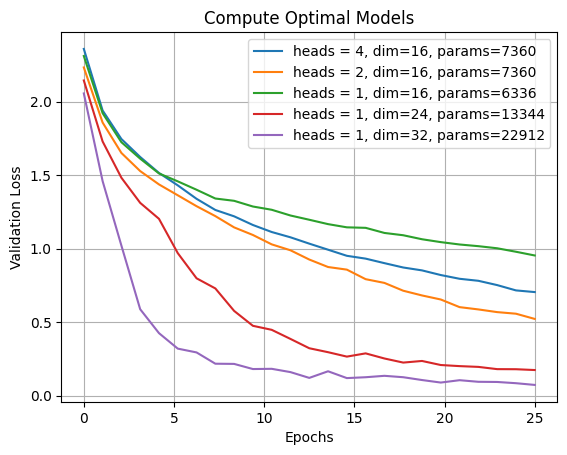

In [32]:

import matplotlib.pyplot as plt
import numpy as np
configs = [
    (16, 4, 4, 64), #(hidden_size, num_heads, num_layers, batch_size)
    (16, 2, 4, 64),
    (16, 1, 4, 64),
    (24, 1, 4, 64),
    (32, 1, 4, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}")

    model = MultiheadDecoderTransformer(
        vocab_size = len(decoder_ds_small.idx_to_token),
        hidden_size = hidden_size,
        num_layers = num_layers,
        num_heads = num_heads
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = decoder_ds_small,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = batch_size
    )

    print(decoder_translate("the air conditioning is working", model, decoder_ds_small))

    parameters = calc_parameters_decoder(model)
    x_points = np.linspace(0, len(results['val_loss']), len(results['val_loss']))
    plt.plot(
        x_points, results['val_loss'], label="heads = {}, dim={}, params={}".format(
            num_heads, hidden_size, parameters
        ))

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title('Compute Optimal Models')
plt.grid()
plt.legend()
plt.show()

In [33]:
plt.clf()

<Figure size 640x480 with 0 Axes>

# Part 3: IsoFLOP Profiling and Scaling Laws
In this final section, you'll compare different architectures based on their compute efficiency. You will also determine the optimal number of parameters and tokens for a fixed compute budget.

While this section does not require any additional code from you, **use the output of it to guide your written responses**.

In [34]:
from hw_utils import (
    plot_scaling_law,
    plot_scaling_law_poly,
    interpolate,
    plot_flops_tokens,
    plot_isoflop,
    plot_flops_params
)

import numpy as np

## Step 1: Train models, Compare FLOPS vs Validation Loss

We'll inspect the compute efficiency of different models by plotting their validation loss against the number of FLOPs used in training up to that point.

In [35]:

configs = [
    (40, 2, 4, 256), #(hidden_size, num_heads, num_layers, batch_size)
    (32, 2, 4, 128),
    (24, 2, 4, 64),
    (16, 1, 4, 64),
    (16, 1, 3, 64),
    (12, 1, 3, 64),
    (12, 1, 2, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}")

    model = MultiheadDecoderTransformer(
        vocab_size = len(decoder_ds_large.idx_to_token),
        hidden_size = hidden_size,
        num_layers = num_layers,
        num_heads = num_heads
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = decoder_ds_large,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = batch_size
    )

    parameters = calc_parameters_decoder(model)
    all_results[parameters] = results



Training model: hidden_size=40, num_heads=2, num_layers=4
Epoch 1 | Train loss: 4.389504 | Val loss 1.381879
Epoch 2 | Train loss: 1.029189 | Val loss 0.645992
Epoch 3 | Train loss: 0.392981 | Val loss 0.208895
Epoch 4 | Train loss: 0.171785 | Val loss 0.114708
Epoch 5 | Train loss: 0.102604 | Val loss 0.071098
Epoch 6 | Train loss: 0.062548 | Val loss 0.059575
Epoch 7 | Train loss: 0.047370 | Val loss 0.038856
Epoch 8 | Train loss: 0.034874 | Val loss 0.025715
Epoch 9 | Train loss: 0.021279 | Val loss 0.026988
Epoch 10 | Train loss: 0.017539 | Val loss 0.027683
Epoch 11 | Train loss: 0.013540 | Val loss 0.015223
Epoch 12 | Train loss: 0.009783 | Val loss 0.015416
Epoch 13 | Train loss: 0.010857 | Val loss 0.016555
Epoch 14 | Train loss: 0.008699 | Val loss 0.017322
Epoch 15 | Train loss: 0.008620 | Val loss 0.015048
Epoch 16 | Train loss: 0.011216 | Val loss 0.018958
Epoch 17 | Train loss: 0.006684 | Val loss 0.014570
Epoch 18 | Train loss: 0.004110 | Val loss 0.011411
Epoch 19 | Tra

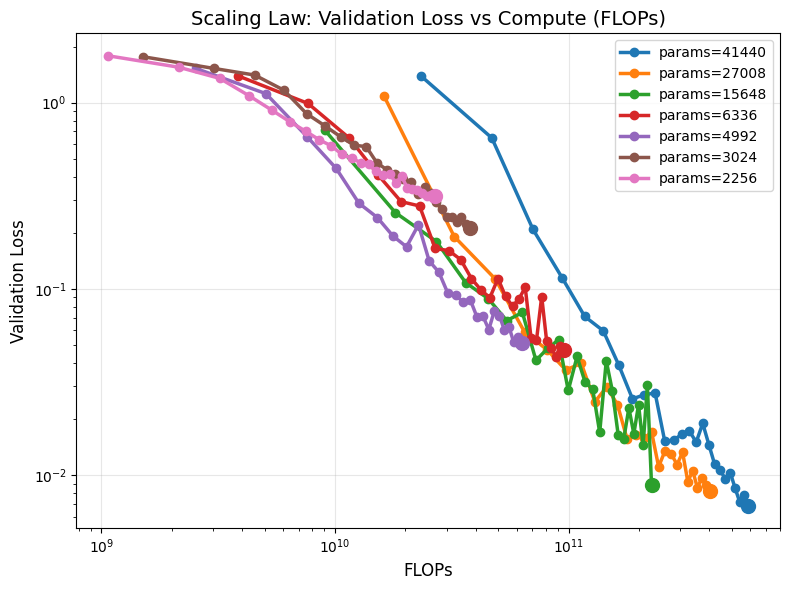

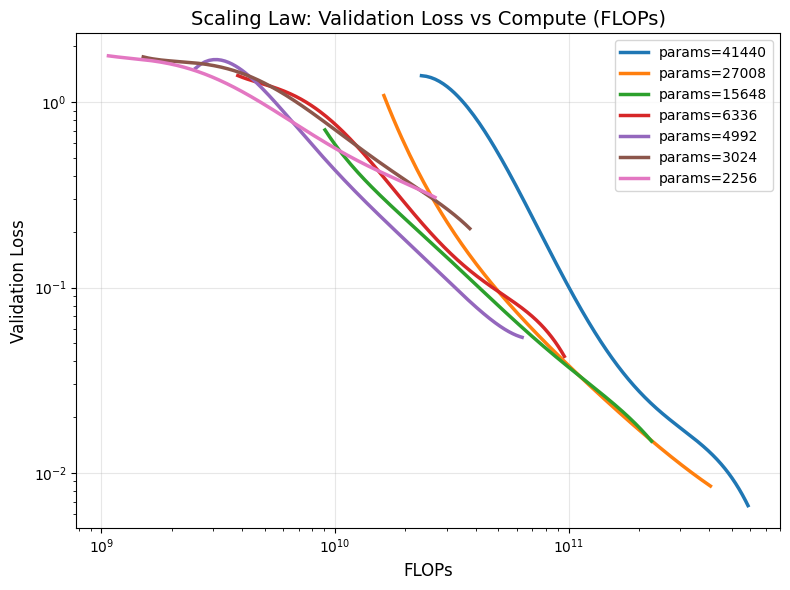

In [36]:
plot_scaling_law(all_results)

plot_scaling_law_poly(all_results)

## Step 2: Optimal Number of Parameters

Using the previously created training runs, we'll fit quadratic functions to the (parameter count, validation loss) pairs to estimate the optimal number of parameters for a given compute budget. We'll then fit a line to this set of optimal parameters to estimate the optimal number of parameters for a compute budget of 1e15.

In [37]:
def find_optim_params(params, loss):
    x = np.array(params)
    y = np.array(loss)

    p = np.polyfit(np.log10(x), y, 2)
    optimal_log_params = -(p[1]) / (2 * p[0])
    optimal_params = 10**(optimal_log_params)

    return optimal_params


target_flops = [8e9, 16e9, 32e9, 64e9, 128e9]
colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00']
params_vs_loss = []
optimal_params = []

for target in target_flops:
  parameters = []
  val_loss = []

  for params, results in all_results.items():
    loss = interpolate(results['val_loss'], results['flops'], target, deg=4)
    # interpolate returns None if target is out of range
    if loss != None:
      parameters.append(params)
      val_loss.append(loss)

  sorted_indices = torch.argsort(torch.tensor(parameters))
  parameters = torch.tensor(parameters)[sorted_indices]
  val_loss = torch.tensor(val_loss)[sorted_indices]

  optimal_params.append(find_optim_params(parameters, val_loss))
  params_vs_loss.append((parameters.tolist(), val_loss.tolist()))


8.00 GFlops: Optimal params = 102,168
16.00 GFlops: Optimal params = 6,040
32.00 GFlops: Optimal params = 7,367
64.00 GFlops: Optimal params = 12,250
128.00 GFlops: Optimal params = 26,246


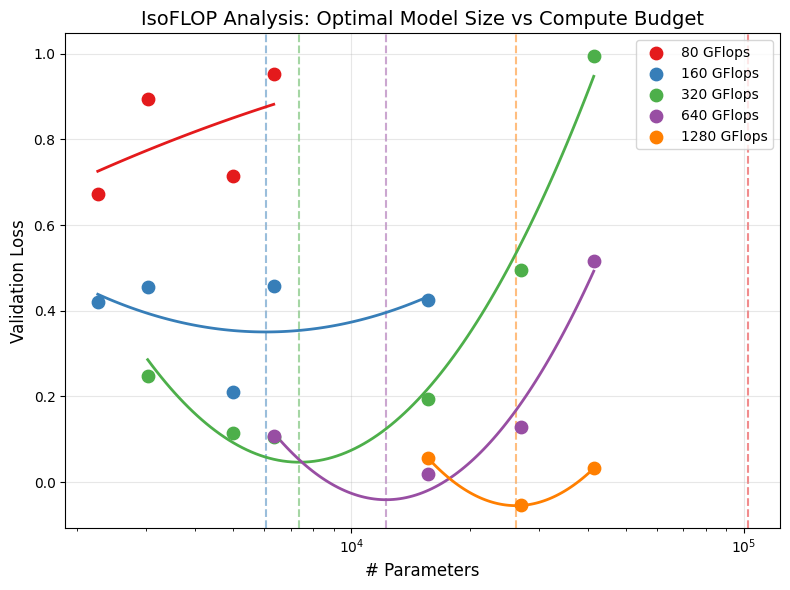

In [38]:
plot_isoflop(target_flops, colors, params_vs_loss, optimal_params)

y = -0.2901210086573424x + 7.280727708454829


/content/drive/MyDrive/NNDL_hw2/hw_utils.py:246: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = "lower left")


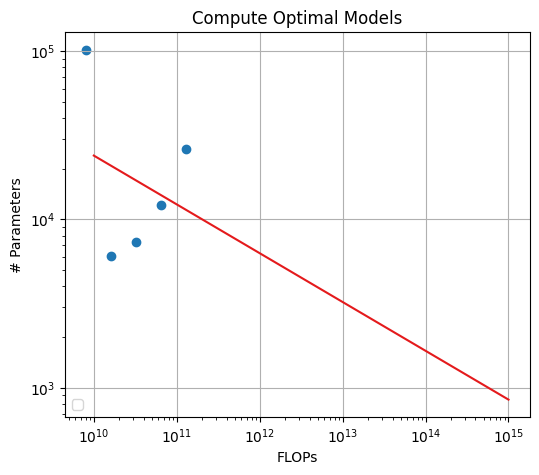

In [39]:
plot_flops_params(target_flops, optimal_params)

## Step 3: Optimal Number of Tokens

Finally, we'll perform a similar analysis to the previous step, only this time determining the optimal number of tokens for a budget of 1e15 flops.

y = 0.5179446226952478x + 0.5871094543656805


/content/drive/MyDrive/NNDL_hw2/hw_utils.py:287: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = "lower left")


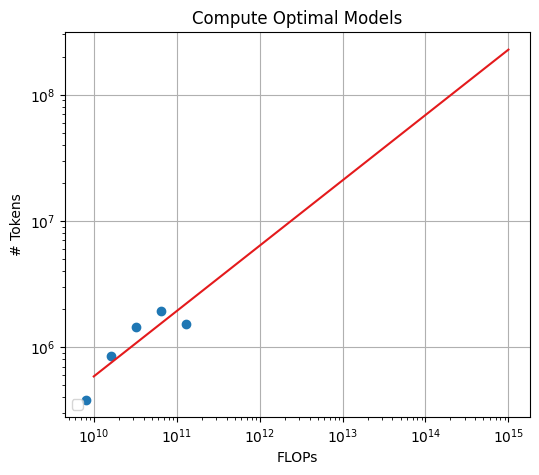

In [40]:
plot_flops_tokens(target_flops, optimal_params, all_results)